---
title: "幾何学的領域上のサンプリング方法"
description: "一様乱数を入力として、逆関数法により幾何学的領域上の確率分布を生成する手順を整理する"
date: 2025-08-19T09:00:00+09:00
date-modified: 2025-09-05T09:00:00+09:00
categories:
  - computerscience
draft: false
---

幾何学的領域上のサンプリング手順（逆関数法ベース）

1. 領域の定義と座標系の設定  
    対象領域を決定し，点を表す座標系を選ぶ（直交座標，極座標など）．
2. 同時確率密度関数（PDF）の決定  
    領域の測度（長さ・面積・体積）を $M$ とし，領域内で $p=\frac{1}{M}$ ，領域外で $p=0$ とする．一様分布だけでなく，任意の確率密度関数を設定することも可能．
3. 必要な変数の周辺確率密度関数の導出  
    多変数の場合は，周辺確率密度関数を導出する．変数間に依存関係がある場合や領域が複雑な場合には，条件付き確率密度関数や座標変換を考慮する．
4. 累積分布関数（CDF）の導出  
    各変数の確率密度関数を積分し，累積分布関数を導出する．
5. 逆関数の計算と乱数生成  
    一様乱数 $\zeta\sim U(0,1)$ を累積分布関数の逆関数に代入し，サンプル値を得る．
6. 必要に応じて座標変換  
    元の座標系に変換し，最終的なサンプル点を構成する．

In [ ]:
import math
import numpy as np
import inspect
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# from matplotlib import font_manager
from typing import Any, Callable, Sequence, TypedDict


np.random.seed(1)

# print(plt.style.available)
plt.style.use("seaborn-v0_8")


def trim_axes(fig: plt.Figure, axs: np.ndarray, num_to_keep: int) -> np.ndarray:
    for ax in axs[num_to_keep:]:
        fig.delaxes(ax)

    return axs[: len(distr_infos)]


# https://stackoverflow.com/a/50664367
def compute_equal_axes_limits(ax):
    axes_lims = (ax.get_xlim(), ax.get_ylim(), ax.get_zlim()) if hasattr(ax, "get_zlim") else (ax.get_xlim(), ax.get_ylim())
    limits = np.array(axes_lims)
    center = limits.mean(axis=1)
    half_extent = 0.5 * np.max(np.abs(limits[:, 1] - limits[:, 0]))
    limits[:, 0] = center - half_extent
    limits[:, 1] = center + half_extent
    return limits


def plot_distribution(ax: plt.Axes, fn, num_samples: int, fn_kwargs: dict[str, Any] | None = None, scatter_args: dict[str, Any] | None = None) -> None:
    if fn_kwargs is None:
        fn_kwargs = {}

    if scatter_args is None:
        scatter_args = {"s": 2, "alpha": 0.6, "edgecolor": "k", "linewidth": 0.01}

    u_args = {arg: np.random.uniform(size=num_samples) for arg in inspect.getfullargspec(fn).args}
    points = fn(**u_args, **fn_kwargs)
    coords = [points[:, i] for i in range(points.shape[-1])]
    ax.scatter(*coords, **scatter_args)


class DistrInfo(TypedDict, total=False):
    fn: Callable[..., Any]
    num_samples: int
    fn_kwargs: dict[str, Any] | None
    title: str


def plot_distributions_2d(distr_infos: list[DistrInfo], nrows_ncols: tuple[int, int] | None = None):
    if nrows_ncols is None:
        nrows_ncols = (1, len(distr_infos))

    base_w, base_h = plt.rcParams.get("figure.figsize")
    figsize = (base_w * nrows_ncols[1] / 2.0, base_h * nrows_ncols[0] / 1.33)
    subplot_kw = {"aspect": "equal", "xlabel": "x", "ylabel": "y"}

    fig, axs = plt.subplots(nrows=nrows_ncols[0], ncols=nrows_ncols[1], sharex="all", sharey="all", subplot_kw=subplot_kw, figsize=figsize, constrained_layout=True)
    axs = trim_axes(fig, np.atleast_1d(axs).flatten(), len(distr_infos))

    fig.set_constrained_layout_pads(hspace=0.1, wspace=0.1)

    for ax, distr_info in zip(axs, distr_infos):
        plot_distribution(ax, distr_info["fn"], distr_info["num_samples"], distr_info.get("fn_kwargs", {}), scatter_args=None)
        limits = compute_equal_axes_limits(ax)
        ax.set_xlim(*limits[0])
        ax.set_ylim(*limits[1])
        ax.grid(True, which="both")
        ax.set_title(distr_info.get("title", None))

    plt.show()


def plot_distributions_3d(distr_infos: list[DistrInfo], nrows_ncols: tuple[int, int] | None = None) -> None:
    if nrows_ncols is None:
        nrows_ncols = (1, len(distr_infos))

    base_w, base_h = plt.rcParams.get("figure.figsize")
    figsize = (base_w * nrows_ncols[1] / 2.0, base_h * nrows_ncols[0] / 1.33)
    subplot_kw = {"projection": "3d", "box_aspect": (1, 1, 1), "xlabel": "x", "ylabel": "y", "zlabel": "z"}

    fig, axs = plt.subplots(nrows=nrows_ncols[0], ncols=nrows_ncols[1], subplot_kw=subplot_kw, figsize=figsize, constrained_layout=True)
    axs = trim_axes(fig, np.atleast_1d(axs).flatten(), len(distr_infos))

    fig.set_constrained_layout_pads(hspace=0.1, wspace=0.1)

    for ax, distr_info in zip(axs, distr_infos):
        plot_distribution(ax, distr_info["fn"], distr_info["num_samples"], distr_info.get("fn_kwargs", {}), scatter_args=None)
        limits = compute_equal_axes_limits(ax)
        ax.set_xlim(*limits[0])
        ax.set_ylim(*limits[1])
        ax.set_zlim(*limits[2])
        ax.grid(True, which="both")
        ax.view_init(elev=20, azim=45)
        ax.set_title(distr_info.get("title", None))

    plt.show()


SAMPLE_SIZES = (500, 2000, 8000)

## １次元サンプリング

### 円周（circle）上の一様分布

確率変数 $\boldsymbol{X}$ が，曲線 $C$ 上に一様分布するとする．

$$
C: \boldsymbol{x}(\phi)=R(\cos\phi\,\boldsymbol{b}_{1}+\sin\phi\,\boldsymbol{b}_{2})
,\quad
0\le\phi\lt 2\pi
$$

同時確率密度関数は曲線 $C$ で定数 $c$ であり，正規化条件を考える．線要素は，

$$
ds
=\left\|\frac{d\boldsymbol{x}}{d\phi}\right\|\,d\phi
=R\,d\phi
$$

したがって，

$$
1
=\int_{C} c\,ds
=\int_{0}^{2\pi} cR\,d\phi
=c\cdot 2\pi R
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{2\pi R}
,\quad
p_{\Phi}(\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{ds}{d\phi}
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Phi}(\zeta)
=2\pi\zeta
$$

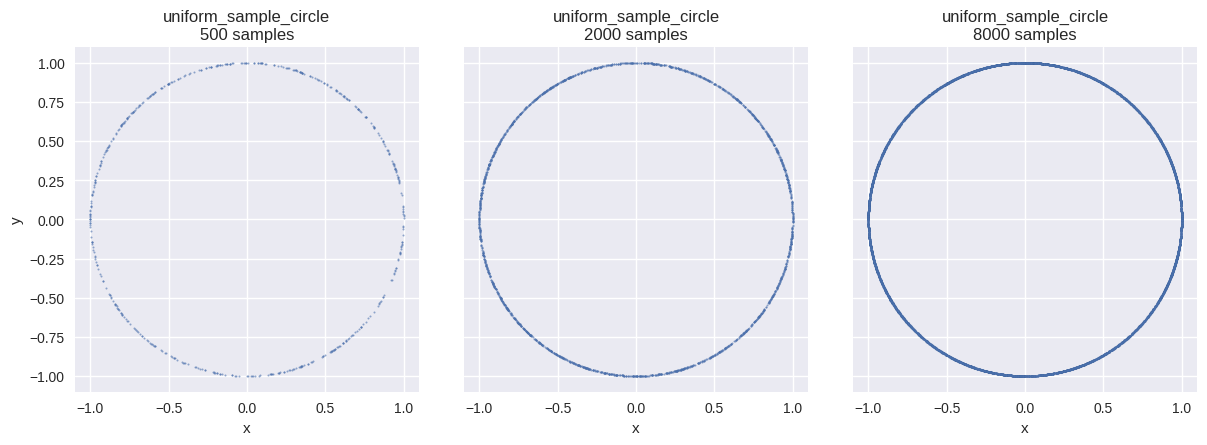

In [ ]:
def uniform_sample_circle(u):
    phi = 2.0 * np.pi * u
    w = (np.cos(phi), np.sin(phi))
    return np.stack(w, axis=-1)


fn = uniform_sample_circle  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos: list[DistrInfo] = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 扇形の円弧（arc）上の一様分布

確率変数 $\boldsymbol{X}$ が，曲線 $C$ 上に一様分布するとする．

$$
C: \boldsymbol{x}(\phi)=R(\cos\phi\,\boldsymbol{b}_{1}+\sin\phi\,\boldsymbol{b}_{2})
,\quad
-\frac{\phi_{\text{max}}}{2}\le\phi \le \frac{\phi_{\text{max}}}{2}
$$

同時確率密度関数は曲線 $C$ で定数 $c$ であり，正規化条件を考える．線要素は，

$$
ds
=\left\|\frac{d\boldsymbol{x}}{d\phi}\right\|\,d\phi
=R\,d\phi
$$

したがって，

$$
1
=\int_{C} c\,ds
=\int_{-\frac{\phi_{\text{max}}}{2}}^{\frac{\phi_{\text{max}}}{2}} cR\,d\phi
=c\cdot R\phi_{\text{max}}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{R\phi_{\text{max}}}
,\quad
p_{\Phi}(\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{ds}{d\phi}
=\frac{1}{\phi_{\text{max}}}
$$

累積分布関数は，

$$
P_{\Phi}(\phi)
=\int_{-\frac{\phi_{\text{max}}}{2}}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi+\frac{\phi_{\text{max}}}{2}}{\phi_{\text{max}}}
$$

逆関数は，

$$
P^{-1}_{\Phi}(\zeta)
=\phi_{\text{max}}\left(\zeta-\frac{1}{2}\right)
$$

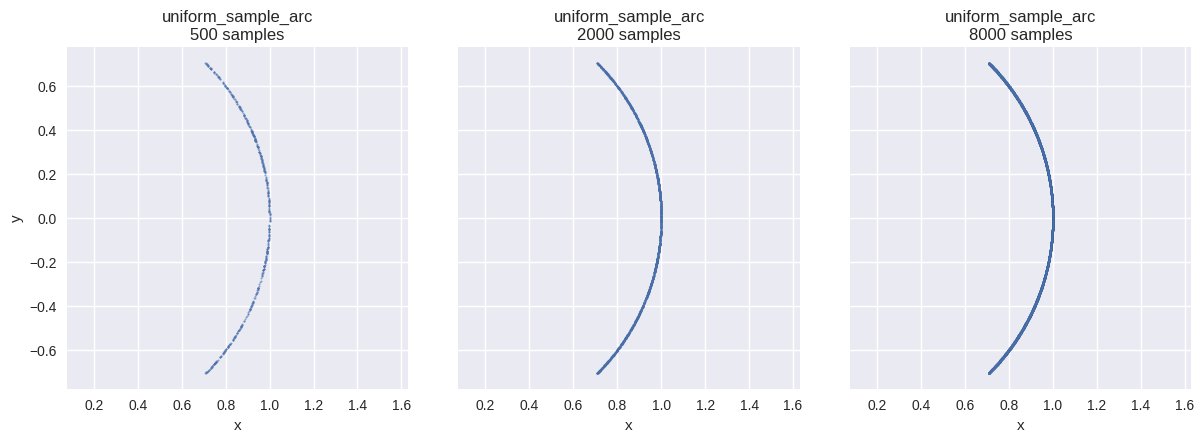

In [ ]:
def uniform_sample_arc(u, *, phi_max=np.pi):
    phi = phi_max * (u - 0.5)
    w = (np.cos(phi), np.sin(phi))
    return np.stack(w, axis=-1)


fn = uniform_sample_arc  # type: ignore
fn_kwargs = {"phi_max": 0.5 * np.pi}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

## ２次元サンプリング

### 平行四辺形（parallelogram）内の一様分布

確率変数 $\boldsymbol{X}$ が、平面上の領域 $S$ 内に一様分布するとする．

$$
S: \boldsymbol{x}(u,v)=\boldsymbol{x}_{1}+u(\boldsymbol{x}_{2}-\boldsymbol{x}_{1})+v(\boldsymbol{x}_{4}-\boldsymbol{x}_{1})
,\quad
0\le u,v\le 1
$$

$\boldsymbol{x}_{i}$ は平行四辺形の頂点であり，辺の対応は，

$$
\boldsymbol{x}_{3}
=\boldsymbol{x}_{2}+\boldsymbol{x}_{4}-\boldsymbol{x}_{1}
$$

で定まるものとする．同時確率密度関数は領域 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial u}\times\frac{\partial\boldsymbol{x}}{\partial v}\right\|\,dudv
=A\,dudv
$$

ここで，平行四辺形の面積を $A=\left\|\frac{\partial\boldsymbol{x}}{\partial u}\times\frac{\partial\boldsymbol{x}}{\partial v}\right\|$ とした．したがって，

$$
1
=\iint_{S} c\,dS
=\int_{0}^{1}\int_{0}^{1} cA\,dudv
=c\cdot A
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{A}
,\quad
p_{U,V}(u,v)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{dudv}
=1
$$

周辺確率密度関数は，

$$
p_{U}(u)
=\int_{0}^{1} p_{U,V}(u,v)\,dv
=1
,\quad
p_{V}(v)
=\int_{0}^{1} p_{U,V}(u,v)\,du
=1
$$

累積分布関数は，

$$
P_{U}(u)
=\int_{0}^{u} p_{U}(t)\,dt
=u
,\quad
P_{V}(v)
=\int_{0}^{v} p_{V}(t)\,dt
=v
$$

逆関数は，

$$
P^{-1}_{U}(\zeta_{1})
=\zeta_{1}
,\quad
P^{-1}_{V}(\zeta_{2})
=\zeta_{2}
$$

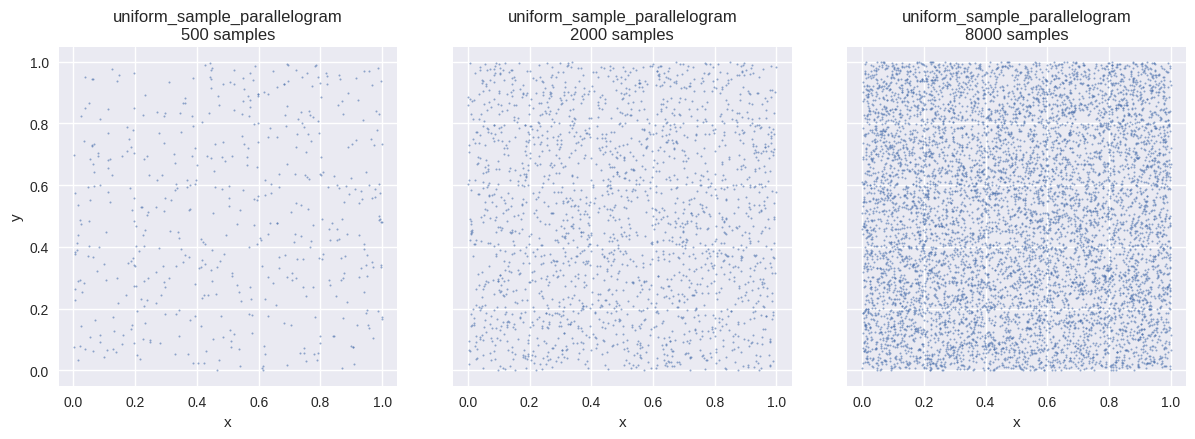

In [ ]:
def uniform_sample_parallelogram(u0, u1):
    return np.stack((u0, u1), axis=-1)


fn = uniform_sample_parallelogram  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 三角形（triangle）内の一様分布

確率変数 $\boldsymbol{X}$ が、平面上の領域 $S$ 内に一様分布するとする．

$$
S: \boldsymbol{x}(\lambda_{1},\lambda_{2})=\lambda_{1}\boldsymbol{x}_{1}+\lambda_{2}\boldsymbol{x}_{2}+(1-\lambda_{1}-\lambda_{2})\boldsymbol{x}_{3}
,\quad
\lambda_{i}\ge 0,\,\lambda_{1}+\lambda_{2}\le 1
$$

同時確率密度関数は領域 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial \lambda_{1}}\times\frac{\partial\boldsymbol{x}}{\partial \lambda_{2}}\right\|\,d\lambda_{1}d\lambda_{2}
=2A\,d\lambda_{1}d\lambda_{2}
$$

ここで，三角形の面積を $A=\frac{1}{2}\left\|\frac{\partial\boldsymbol{x}}{\partial\lambda_{1}}\times\frac{\partial\boldsymbol{x}}{\partial\lambda_{2}}\right\|$ とした．したがって，

$$
1
=\iint_{S} c\,dS
=\int_{0}^{1}\int_{0}^{1-\lambda_{2}} c2A\,d\lambda_{1}d\lambda_{2}
=c\cdot A
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{A}
,\quad
p_{\Lambda_{1},\Lambda_{2}}(\lambda_{1},\lambda_{2})
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{d\lambda_{1}d\lambda_{2}}
=2
$$

周辺確率密度関数は，

$$
p_{\Lambda_{1}}(\lambda_{1})
=\int_{0}^{1-\lambda_{1}} p_{\Lambda_{1},\Lambda_{2}}(\lambda_{1},\lambda_{2})\,d\lambda_{2}
=2(1-\lambda_{1})
,\quad
p_{\Lambda_{2}}(\lambda_{2})
=\int_{0}^{1-\lambda_{2}} p_{\Lambda_{1},\Lambda_{2}}(\lambda_{1},\lambda_{2})\,d\lambda_{1}
=2(1-\lambda_{2})
$$

$\Lambda_{1}, \Lambda_{2}$ は独立ではないので，

$$
p_{\Lambda_{2}|\Lambda_{1}}(\lambda_{2}|\lambda_{1})
=\frac{p_{\Lambda_{1},\Lambda_{2}}(\lambda_{1},\lambda_{2})}{p_{\Lambda_{1}}(\lambda_{1})}
=\frac{1}{1-\lambda_{1}}
$$

累積分布関数は，

$$
P_{\Lambda_{1}}(\lambda_{1})
=\int_{0}^{\lambda_{1}} p_{\Lambda_{1}}(t)\,dt
=2\lambda_{1}-\lambda^{2}_{1}
,\quad
P_{\Lambda_{2}|\Lambda_{1}}(\lambda_{2}|\lambda_{1})
=\int_{0}^{\lambda_{2}} p_{\Lambda_{2}|\Lambda_{1}}(t|\lambda_{1})\,dt
=\frac{\lambda_{2}}{1-\lambda_{1}}
$$

逆関数は，

$$
P^{-1}_{\Lambda_{1}}(\zeta_{1})
=1-\sqrt{1-\zeta_{1}}
,\quad
P^{-1}_{\Lambda_{2}|\Lambda_{1}}(\zeta_{2}|\lambda_{1})
=(1-\lambda_{1})\zeta_{2}
$$

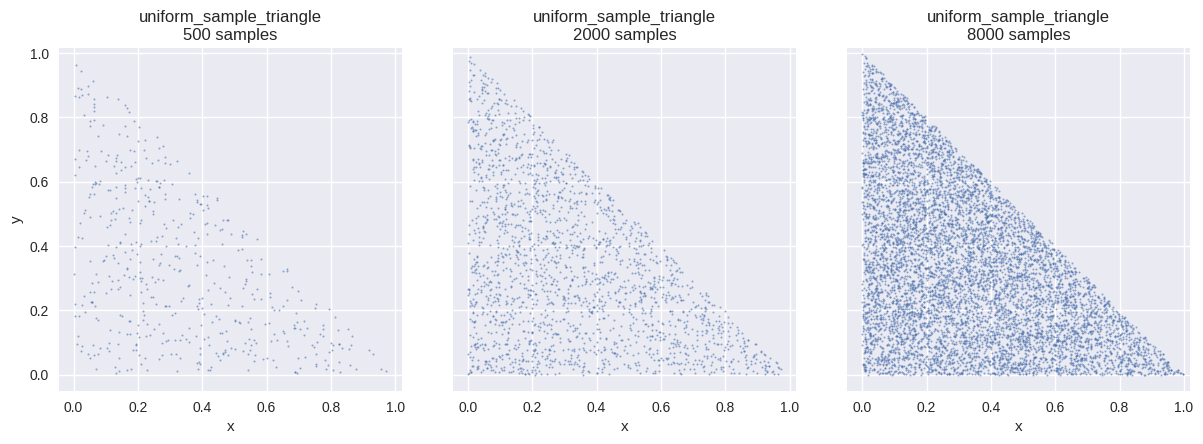

In [ ]:
def uniform_sample_triangle(u0, u1):
    lambda0 = 1.0 - np.sqrt(u0)  # np.sqrt(1.0 - u0)
    lambda1 = (1.0 - lambda0) * u1
    x = (lambda0, lambda1)
    return np.stack(x, axis=-1)


fn = uniform_sample_triangle  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 円板（disk）内の一様分布

確率変数 $\boldsymbol{X}$ が、平面上の領域 $S$ 内に一様分布するとする．

$$
S: \boldsymbol{x}(\rho,\phi)=\rho(\cos\phi\,\boldsymbol{b}_1+\sin\phi\,\boldsymbol{b}_2)
,\quad
0\le\rho\le R,\, 0\le\phi\lt 2\pi
$$

同時確率密度関数は領域 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial\rho}\times\frac{\partial\boldsymbol{x}}{\partial\phi}\right\|\,d\rho d\phi
=\rho\,d\rho d\phi
$$

したがって，

$$
1
=\iint_{S} c\,dS
=\int_{0}^{2\pi}\int_{0}^{R} c\rho\,d\rho d\phi
=c\cdot \pi R^{2}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{\pi R^{2}}
,\quad
p_{\mathrm{P},\Phi}(\rho,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{d\rho d\phi}
=\frac{\rho}{\pi R^{2}}
$$

周辺確率密度関数は，

$$
p_{\mathrm{P}}(\rho)
=\int_{0}^{2\pi} p_{\mathrm{P},\Phi}(\rho,\phi)\,d\phi
=\frac{2\rho}{R^{2}}
,\quad
p_{\Phi}(\phi)
=\int_{0}^{R} p_{\mathrm{P},\Phi}(\rho,\phi)\,d\rho
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\mathrm{P}}(\rho)
=\int_{0}^{\rho} p_{\mathrm{P}}(t)\,dt
=\frac{\rho^{2}}{R^{2}}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\mathrm{P}}(\zeta_{1})
=R\sqrt{\zeta_{1}}
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

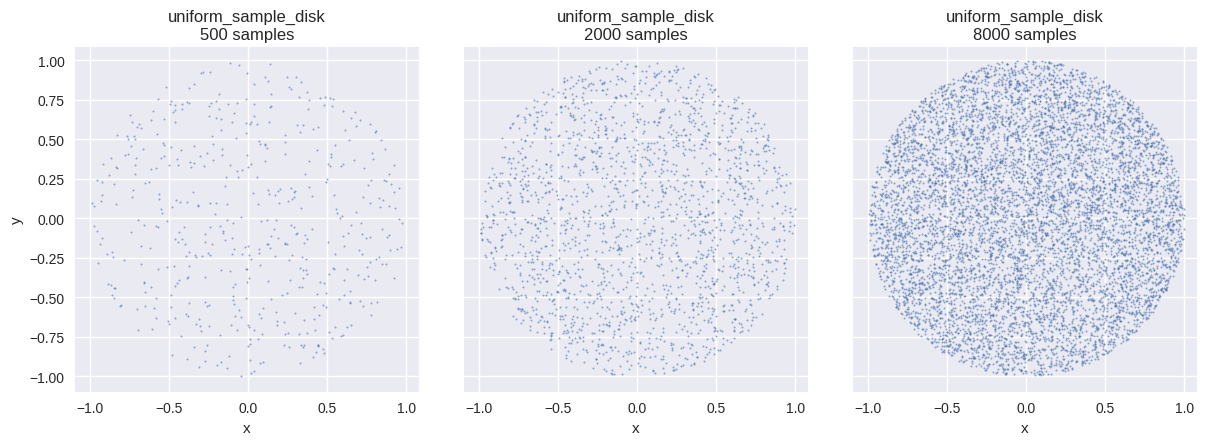

In [ ]:
def uniform_sample_disk(u0, u1):
    rho = np.sqrt(u0)
    phi = 2.0 * np.pi * u1
    x = (np.cos(phi), np.sin(phi))
    return rho[:, np.newaxis] * np.stack(x, axis=-1)


fn = uniform_sample_disk  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 扇形（sector）内の一様分布

確率変数 $\boldsymbol{X}$ が、平面上の領域 $S$ 内に一様分布するとする．

$$
S: \boldsymbol{x}(\rho,\phi)=\rho(\cos\phi\,\boldsymbol{b}_1+\sin\phi\,\boldsymbol{b}_2)
,\quad
0\le\rho\le R,\, -\frac{\phi_{\text{max}}}{2}\le\phi\le\frac{\phi_{\text{max}}}{2}
$$

同時確率密度関数は領域 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial\rho}\times\frac{\partial\boldsymbol{x}}{\partial\phi}\right\|\,d\rho d\phi
=\rho\,d\rho d\phi
$$

したがって，

$$
1
=\iint_{S} c\,dS
=\int_{-\frac{\phi_{\text{max}}}{2}}^{\frac{\phi_{\text{max}}}{2}}\int_{0}^{R} c\rho\,d\rho d\phi
=c\cdot \frac{R^{2}\phi_{\text{max}}}{2}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{2}{R^{2}\phi_{\text{max}}}
,\quad
p_{\mathrm{P},\phi}(\rho,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{d\rho d\phi}
=\frac{2\rho}{R^{2}\phi_{\text{max}}}
$$

周辺確率密度関数は，

$$
p_{\mathrm{P}}(\rho)
=\int_{-\frac{\phi_{\text{max}}}{2}}^{\frac{\phi_{\text{max}}}{2}} p_{\mathrm{P},\phi}(\rho,\phi)\,d\phi
=\frac{2\rho}{R^{2}}
,\quad
p_{\Phi}(\phi)
=\int_{0}^{R} p_{\mathrm{P},\phi}(\rho,\phi)\,d\rho
=\frac{1}{\phi_{\text{max}}}
$$

累積分布関数は，

$$
P_{\mathrm{P}}(\rho)
=\int_{0}^{\rho} p_{\mathrm{P}}(t)\,dt
=\frac{\rho^{2}}{R^{2}}
,\quad
P_{\Phi}(\phi)
=\int_{-\frac{\phi_{\text{max}}}{2}}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi+\frac{\phi_{\text{max}}}{2}}{\phi_{\text{max}}}
$$

逆関数は，

$$
P^{-1}_{\mathrm{P}}(\zeta_{1})
=R\sqrt{\zeta_{1}}
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=\phi_{\text{max}}\left(\zeta_{2}-\frac{1}{2}\right)
$$

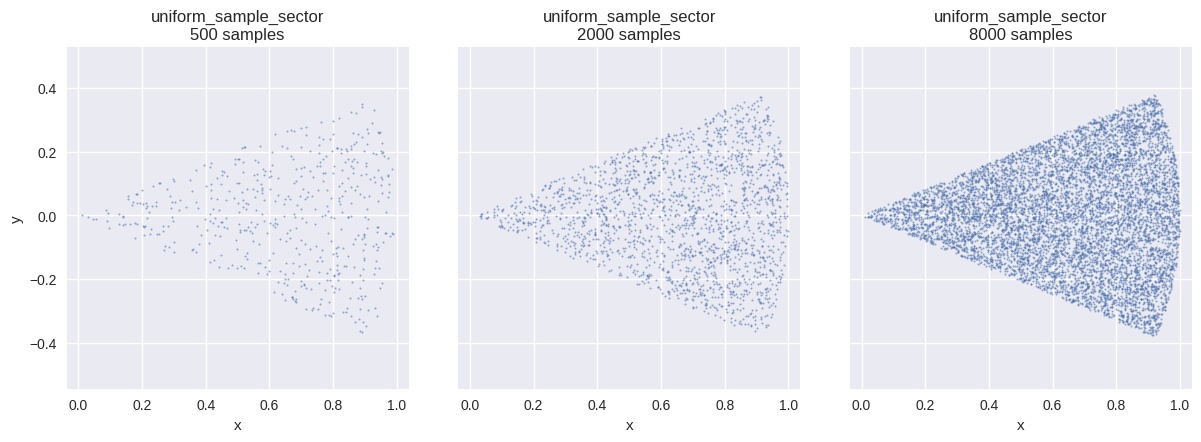

In [ ]:
def uniform_sample_sector(u0, u1, *, phi_max=np.pi):
    rho = np.sqrt(u0)
    phi = phi_max * (u1 - 0.5)
    x = (np.cos(phi), np.sin(phi))
    return rho[:, np.newaxis] * np.stack(x, axis=-1)


fn = uniform_sample_sector  # type: ignore
fn_kwargs = {"phi_max": 0.25 * np.pi}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_2d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 球（sphere）上の一様分布

確率変数 $\boldsymbol{X}$ が，曲面 $S$ 上に一様分布するとする．

$$
S: \boldsymbol{x}(\theta,\phi)=
\begin{pmatrix}
R\sin\theta\cos\phi\\
R\sin\theta\sin\phi\\
R\cos\theta
\end{pmatrix}
,\quad
0\le\theta\le\pi,\,0\le\phi\lt 2\pi
$$

同時確率密度関数は曲面 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial\theta}\times\frac{\partial\boldsymbol{x}}{\partial\phi}\right\|\,d\theta d\phi
=R^{2}\sin\theta\,d\theta d\phi
$$

したがって，

$$
1
=\int_{S} c\,dS
=\int_{0}^{2\pi}\int_{0}^{\pi} cR^{2}\sin\theta\,d\theta d\phi
=c\cdot 4\pi R^{2}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{4\pi R^{2}}
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{d\theta d\phi}
=\frac{\sin\theta}{4\pi}
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=\frac{\sin\theta}{2}
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos\theta}{2}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arccos(1-2\zeta_{1})
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

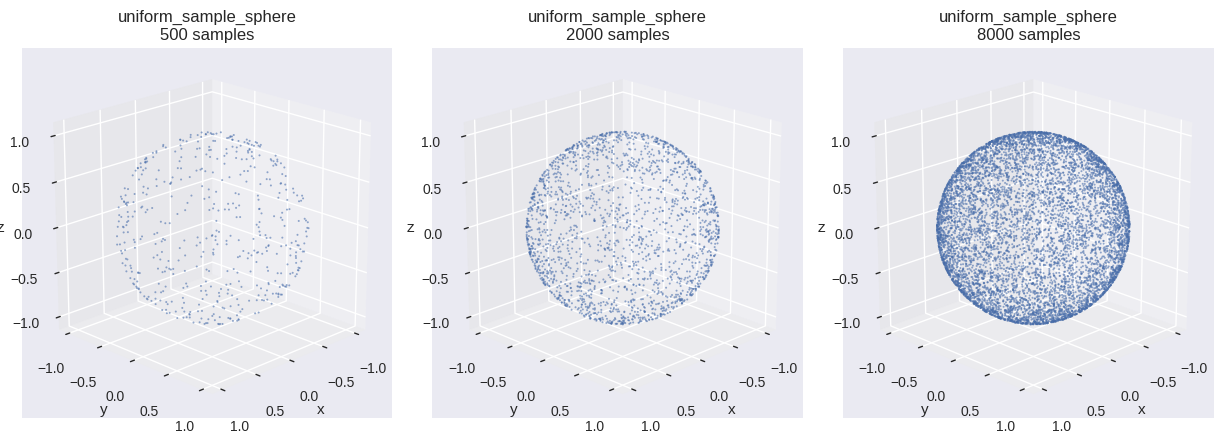

In [ ]:
def uniform_sample_sphere(u0, u1):
    c = 1.0 - 2.0 * u0
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = uniform_sample_sphere  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 球冠（spherical cap）上の一様分布

確率変数 $\boldsymbol{X}$ が，曲面 $S$ 上で一様分布するとする．

$$
S: \boldsymbol{x}(\theta,\phi)=
\begin{pmatrix}
R\sin\theta\cos\phi\\
R\sin\theta\sin\phi\\
R\cos\theta
\end{pmatrix}
,\quad
0\le\theta\le\theta_{\text{max}},\,0\le\phi\lt 2\pi
$$

同時確率密度関数は曲面 $S$ で定数 $c$ であり，正規化条件を考える．面積要素は，

$$
dS
=\left\|\frac{\partial\boldsymbol{x}}{\partial\theta}\times\frac{\partial\boldsymbol{x}}{\partial\phi}\right\|\,d\theta d\phi
=R^{2}\sin\theta\,d\theta d\phi
$$

したがって，

$$
1
=\int_{S} c\,dS
=\int_{0}^{2\pi}\int_{0}^{\theta_{\text{max}}} cR^{2}\sin\theta\,d\theta d\phi
=c\cdot 2\pi R^{2}(1-\cos\theta_{\text{max}})
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{2\pi R^{2}(1-\cos\theta_{\text{max}})}
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dS}{d\theta d\phi}
=\frac{\sin\theta}{2\pi(1-\cos\theta_{\text{max}})}
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=\frac{\sin\theta}{1-\cos\theta_{\text{max}}}
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\theta_{\text{max}}} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos\theta}{1-\cos\theta_{\text{max}}}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arccos(1-(1-\cos\theta_{\text{max}})\zeta_{1})
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

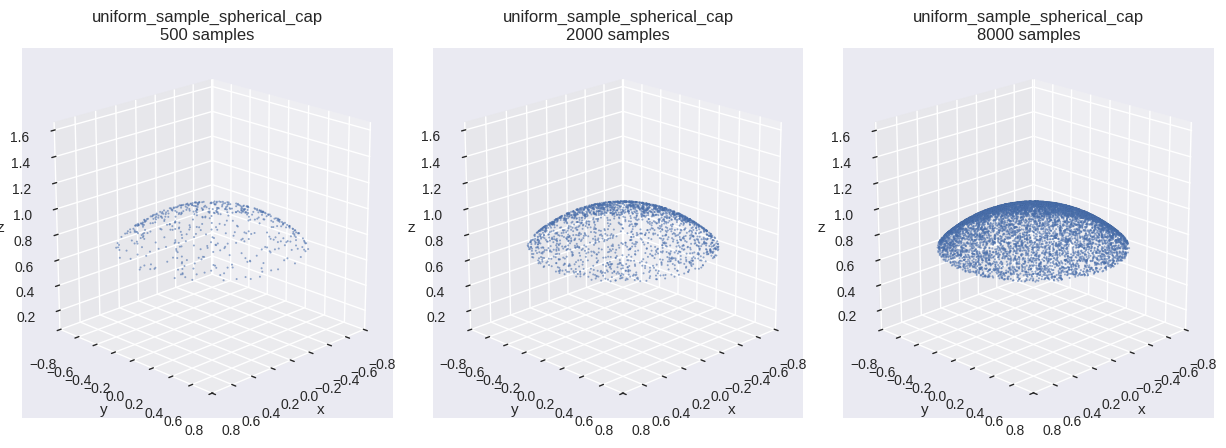

In [ ]:
def uniform_sample_spherical_cap(u0, u1, *, cos_theta_max=np.pi):
    c = 1.0 - (1.0 - cos_theta_max) * u0
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = uniform_sample_spherical_cap  # type: ignore
fn_kwargs = {"cos_theta_max": np.cos(0.25 * np.pi)}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 単位半球（unit hemisphere）上の分布

確率変数 $\boldsymbol{\Omega}$ が，単位半球上に分布するとする．

$$
H^{2}: \boldsymbol{\omega}(\theta, \phi)=
\begin{pmatrix}
\sin\theta\cos\phi\\
\sin\theta\sin\phi\\
\cos\theta
\end{pmatrix}
,\quad 0\le\theta\le \frac{\pi}{2},\,0\le\phi\lt 2\pi
$$

球面上の面積要素は，

$$
dA
=\left\|\frac{\partial\boldsymbol{\omega}}{\partial\theta}\times\frac{\partial\boldsymbol{\omega}}{\partial\phi}\right\|\,d\theta d\phi
=\sin\theta\,d\theta d\phi
$$

であり，半径 $r=1$ の単位球で立体角要素は，

$$
d\omega=\frac{dA}{r^{2}}=dA=\sin\theta\,d\theta d\phi
$$

したがって，立体角上で定義された確率密度関数 $p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})$ は，測度変換により極座標系での同時確率密度関数 $p_{\Theta,\Phi}(\theta,\phi)$ に次のように変換される．

$$
p_{\Theta,\Phi}(\theta,\phi)
=p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})\frac{d\omega}{d\theta d\phi}
=p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})\sin\theta
$$

#### 一様分布

確率変数 $\boldsymbol{\Omega}$ が，単位半球上に一様分布するとする．このとき，同時確率密度関数は定数 $c$ であり，正規化条件を考える．

$$
1
=\int_{H^{2}} c\,d\omega
=\int_{0}^{2\pi}\int_{0}^{\frac{\pi}{2}} c\sin\theta\,d\theta d\phi
=c\cdot 2\pi
$$

同時確率密度関数は，

$$
p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})
=\frac{1}{2\pi}
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=\frac{\sin\theta}{2\pi}
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=\sin\theta
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\frac{\pi}{2}} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=1-\cos\theta
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arccos(1-\zeta_{1})
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

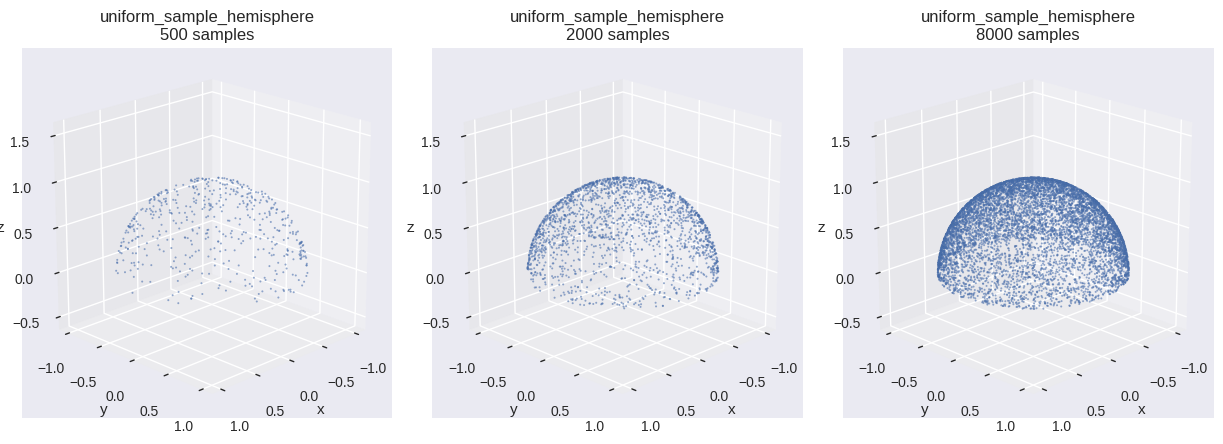

In [ ]:
def uniform_sample_hemisphere(u0, u1):
    c = u0  # 1 - u0
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = uniform_sample_hemisphere  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

#### コサイン重み付き分布

確率変数 $\boldsymbol{\Omega}$ が，単位半球上に $\cos\theta$ に比例分布するとする．このとき，同時確率密度関数は $c\cos\theta$ であり，正規化条件を考える．

$$
1
=\int_{H^{2}} c\cos\theta\,d\omega
=\int_{0}^{2\pi}\int_{0}^{\frac{\pi}{2}} c\cos\theta\sin\theta\,d\theta d\phi
=c\cdot 2\pi\int_{0}^{1} u\,du
=c\cdot\pi
$$

同時確率密度関数は，

$$
p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})
=\frac{\cos\theta}{\pi}
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=\frac{\sin 2\theta}{2\pi}
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=\sin 2\theta
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\frac{\pi}{2}} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos 2\theta}{2}
=\sin^{2}\theta
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arcsin\sqrt{\zeta_{1}}
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

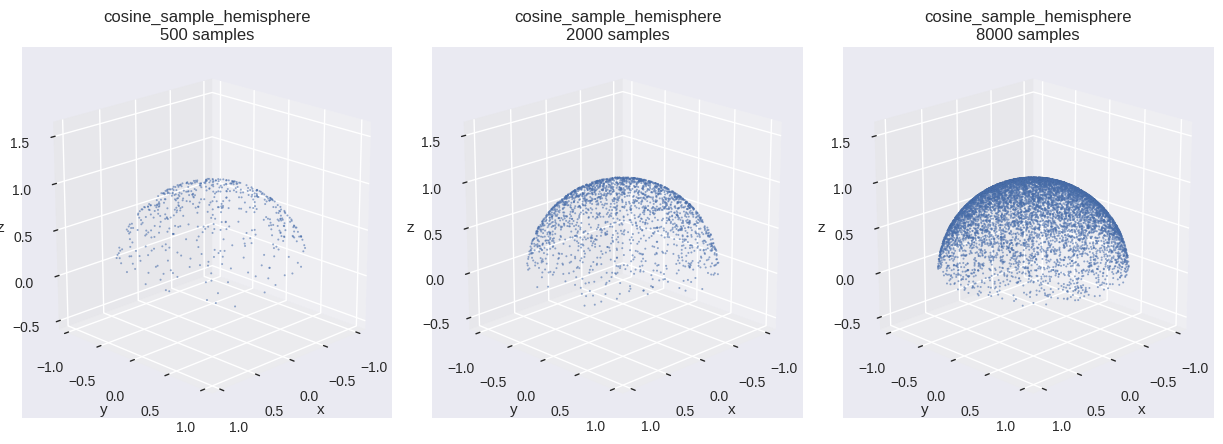

In [ ]:
def cosine_sample_hemisphere(u0, u1):
    s = np.sqrt(u0)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), np.sqrt(1.0 - u0))  # since u0 represents sin^2(theta)
    return np.stack(w, axis=-1)


fn = cosine_sample_hemisphere  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

#### Phong Specular Lobe 分布

確率変数 $\boldsymbol{\Omega}$ が，単位半球上に $\cos^{n}\theta$ に比例分布するとする．このとき，同時確率密度関数は $c\cos^{n}\theta$ であり，正規化条件を考える．

$$
1
=\int_{H^{2}} c\cos^{n}\theta\,d\omega
=\int_{0}^{2\pi}\int_{0}^{\frac{\pi}{2}} c\cos^{n}\theta\sin\theta\,d\theta d\phi
=c\cdot 2\pi\int_{0}^{1} u^{n}\,du
=c\cdot \frac{2\pi}{n+1}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})
=\frac{n+1}{2\pi}\cos^{n}\theta
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=\frac{n+1}{2\pi}\cos^{n}\theta\sin\theta
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=(n+1)\cos^{n}\theta\sin\theta
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\frac{\pi}{2}} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=1-\cos^{n+1}\theta
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arccos\sqrt[n+1]{1-\zeta_{1}}
\hspace{0.5em},\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

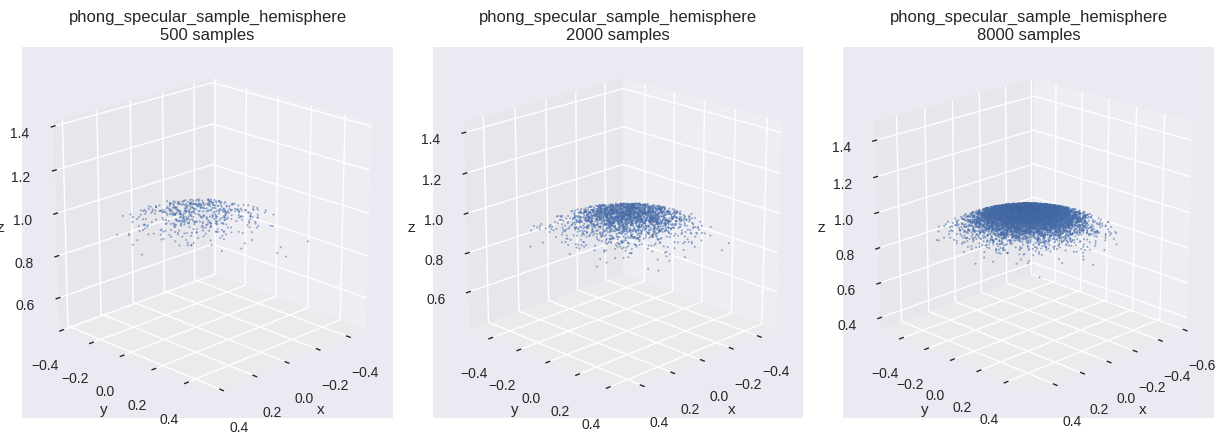

In [ ]:
def phong_specular_sample_hemisphere(u0, u1, *, n=2):
    c = (1.0 - u0) ** (1.0 / (n + 1))
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = phong_specular_sample_hemisphere  # type: ignore
fn_kwargs = {"n": 50}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

#### Microfacet GGX Specular Lobe 分布

確率変数 $\boldsymbol{\Omega}$ が，単位半球上に $D(\theta)\cos\theta$ に比例分布するとする．ここで GGX の NDF を，

$$
D(\theta)
=\frac{\alpha^{2}}{\pi\left(\cos^{2}\theta\,(\alpha^{2}-1)+1\right)^{2}}
$$

と定める．同時確率密度関数は $cD(\theta)\cos\theta$ であり，正規化条件を考える．

$$
\begin{align*}
1
&=\int_{H^{2}} cD(\theta)\cos\theta\,d\omega
=\int_{0}^{2\pi}\int_{0}^{\frac{\pi}{2}} cD(\theta)\cos\theta\sin\theta\,d\theta d\phi\\
&=c\cdot\alpha^{2}\int_{0}^{1}\frac{1}{\left(u(\alpha^{2}-1)+1 \right)^{2}}\,du
\quad(u=\cos^{2}\theta)\\
&=c\cdot\frac{\alpha^{2}}{\alpha^{2}-1}\int_{1}^{\alpha^{2}}\frac{1}{v^{2}}\,dv
\quad(v=u(\alpha^{2}-1)+1)\\
&=c
\end{align*}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{\Omega}}(\boldsymbol{\omega})
=D(\theta)\cos\theta
,\quad
p_{\Theta,\Phi}(\theta,\phi)
=D(\theta)\cos\theta\sin\theta
$$

周辺確率密度関数は，

$$
p_{\Theta}(\theta)
=\int_{0}^{2\pi} p_{\Theta,\Phi}(\theta,\phi)\,d\phi
=2\pi D(\theta)\cos\theta\sin\theta
,\quad
p_{\Phi}(\phi)
=\int_{0}^{\frac{\pi}{2}} p_{\Theta,\Phi}(\theta,\phi)\,d\theta
=\frac{1}{2\pi}
$$

累積分布関数は，

$$
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos^{2}\theta}{\cos^{2}\theta\,(\alpha^{2}-1)+1}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{\Theta}(\zeta_{1})
=\arccos\sqrt{\frac{1-\zeta_{1}}{(\alpha^{2}-1)\zeta_{1}+1}}
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
$$

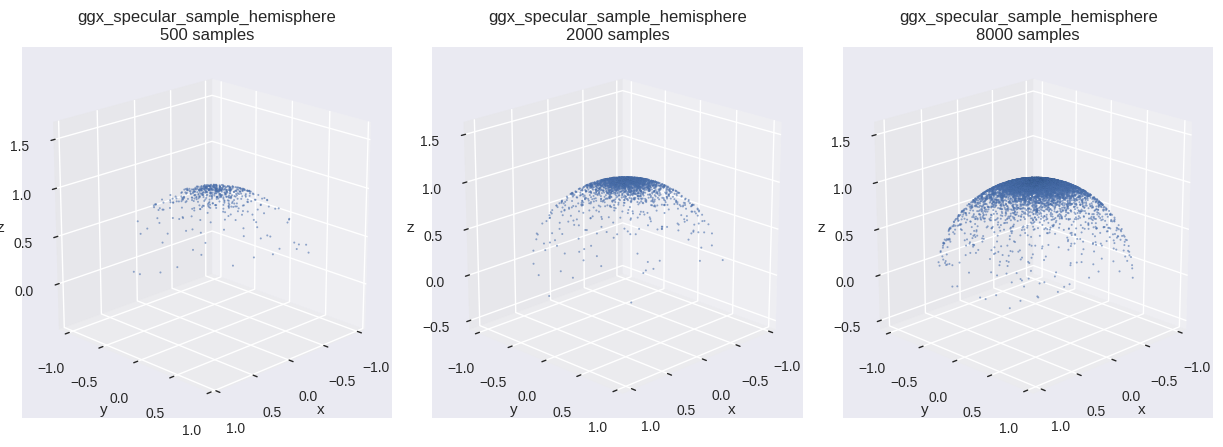

In [ ]:
def ggx_specular_sample_hemisphere(u0, u1, *, alpha=1.0):
    c = np.sqrt((1.0 - u0) / ((alpha * alpha - 1.0) * u0 + 1.0))
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u1
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = ggx_specular_sample_hemisphere  # type: ignore
roughness = 0.5
fn_kwargs = {"alpha": roughness**2.0}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

## ３次元サンプリング

### 球体（ball）内の一様分布

確率変数 $\boldsymbol{X}$ が領域 $V$ 内に一様分布するとする．

$$
V: \boldsymbol{x}(r,\theta,\phi)=
\begin{pmatrix}
r\sin\theta\cos\phi\\
r\sin\theta\sin\phi\\
r\cos\theta
\end{pmatrix}
,\quad
0\le r\le R,\,0\le\theta\le\pi,\,0\le\phi\lt 2\pi
$$

同時確率密度関数は領域 $V$ で定数 $c$ であり，正規化条件を考える．体積要素は，

$$
dV
=\left|\frac{\partial(x,y,z)}{\partial(r,\theta,\phi)}\right|\,drd\theta d\phi
=r^{2}\sin\theta\,drd\theta d\phi
$$

したがって，

$$
1
=\int_{V} c\,dV
=\int_{0}^{2\pi}\int_{0}^{\pi}\int_{0}^{R} cr^{2}\sin\theta\,drd\theta d\phi
=c\cdot\frac{4\pi R^{3}}{3}
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{3}{4\pi R^{3}}
,\quad
p_{R,\Theta,\Phi}(r,\theta,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dV}{drd\theta d\phi}
=\frac{3}{4\pi R^{3}}r^{2}\sin\theta
$$

周辺確率密度関数は，

$$
\begin{align*}
p_{R}(r)
&=\int_{0}^{2\pi}\int_{0}^{\pi} p_{R,\Theta,\Phi}(r,\theta,\phi)\,d\theta d\phi
=\frac{3r^{2}}{R^{3}}\\
p_{\Theta}(\theta)
&=\int_{0}^{2\pi}\int_{0}^{R} p_{R,\Theta,\Phi}(r,\theta,\phi)\,drd\phi
=\frac{\sin\theta}{2}\\
p_{\Phi}(\phi)
&=\int_{0}^{\pi}\int_{0}^{R} p_{R,\Theta,\Phi}(r,\theta,\phi)\,drd\theta
=\frac{1}{2\pi}
\end{align*}
$$

累積分布関数は，

$$
P_{R}(r)
=\int_{0}^{r} p_{R}(t)\,dt
=\frac{r^{3}}{R^{3}}
,\quad
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos\theta}{2}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{R}(\zeta_{1})
=R\sqrt[3]{\zeta_{1}}
,\quad
P^{-1}_{\Theta}(\zeta_{2})
=\arccos(1-2\zeta_{2})
,\quad
P^{-1}_{\Phi}(\zeta_{3})
=2\pi\zeta_{3}
$$

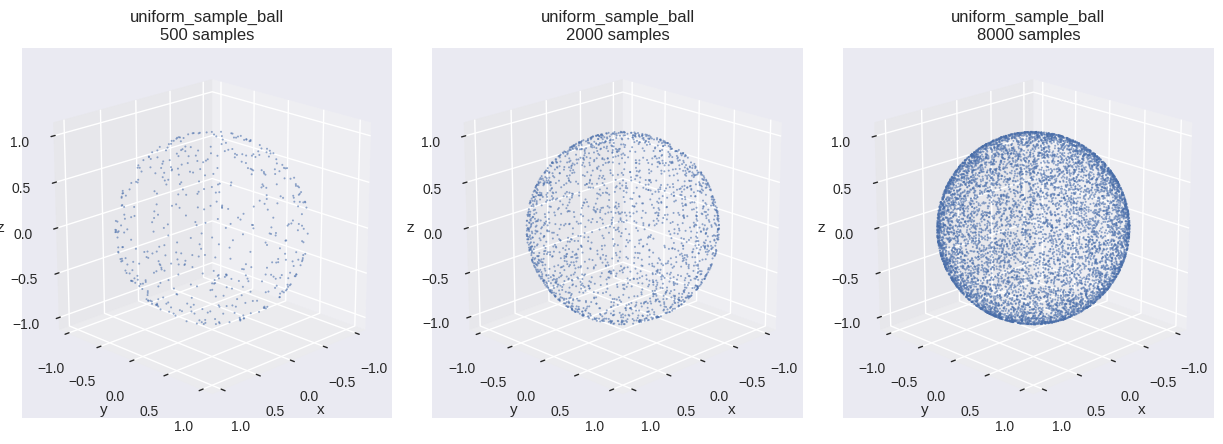

In [ ]:
def uniform_sample_ball(u0, u1, u2):
    radius = np.cbrt(u0)
    c = 1.0 - 2.0 * u1
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u2
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return np.stack(w, axis=-1)


fn = uniform_sample_ball  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 球扇形（spherical sector）内の一様分布

確率変数 $\boldsymbol{X}$ が領域 $V$ 内に一様分布するとする．

$$
V: \boldsymbol{x}(r,\theta,\phi)=
\begin{pmatrix}
r\sin\theta\cos\phi\\
r\sin\theta\sin\phi\\
r\cos\theta
\end{pmatrix}
,\quad
0\le r\le R,\,0\le\theta\le\theta_{\text{max}},\,0\le\phi\lt 2\pi
$$

同時確率密度関数は領域 $V$ で定数 $c$ であり，正規化条件を考える．体積要素は，

$$
dV
=\left|\frac{\partial(x,y,z)}{\partial(r,\theta,\phi)}\right|\,drd\theta d\phi
=r^{2}\sin\theta\,drd\theta d\phi
$$

したがって，

$$
1
=\int_{V} c\,dV
=\int_{0}^{2\pi}\int_{0}^{\theta_{\text{max}}}\int_{0}^{R} cr^{2}\sin\theta\,drd\theta d\phi
=c\cdot\frac{2\pi R^{3}}{3}(1-\cos\theta_{\text{max}})
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{3}{2\pi R^{3}(1-\cos\theta_{\text{max}})}
,\quad
p_{R,\Theta,\Phi}(r,\theta,\phi)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dV}{drd\theta d\phi}
=\frac{3r^{2}\sin\theta}{2\pi R^{3}(1-\cos\theta_{\text{max}})}
$$

周辺確率密度関数は，

$$
\begin{align*}
p_{R}(r)
&=\int_{0}^{2\pi}\int_{0}^{\theta_{\text{max}}} p_{R,\Theta,\Phi}(r,\theta,\phi)\,d\theta d\phi
=\frac{3r^{2}}{R^{3}}\\
p_{\Theta}(\theta)
&=\int_{0}^{2\pi}\int_{0}^{R} p_{R,\Theta,\Phi}(r,\theta,\phi)\,drd\phi
=\frac{\sin\theta}{1-\cos\theta_{\text{max}}}\\
p_{\Phi}(\phi)
&=\int_{0}^{\theta_{\text{max}}}\int_{0}^{R} p_{R,\Theta,\Phi}(r,\theta,\phi)\,drd\theta
=\frac{1}{2\pi}
\end{align*}
$$

累積分布関数は，

$$
P_{R}(r)
=\int_{0}^{r} p_{R}(t)\,dt
=\frac{r^{3}}{R^{3}}
,\quad
P_{\Theta}(\theta)
=\int_{0}^{\theta} p_{\Theta}(t)\,dt
=\frac{1-\cos\theta}{1-\cos\theta_{\text{max}}}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
$$

逆関数は，

$$
P^{-1}_{R}(\zeta_{1})
=R\sqrt[3]{\zeta_{1}}
,\quad
P^{-1}_{\Theta}(\zeta_{2})
=\arccos(1-(1-\cos\theta_{\text{max}})\zeta_{2})
,\quad
P^{-1}_{\Phi}(\zeta_{3})
=2\pi\zeta_{3}
$$

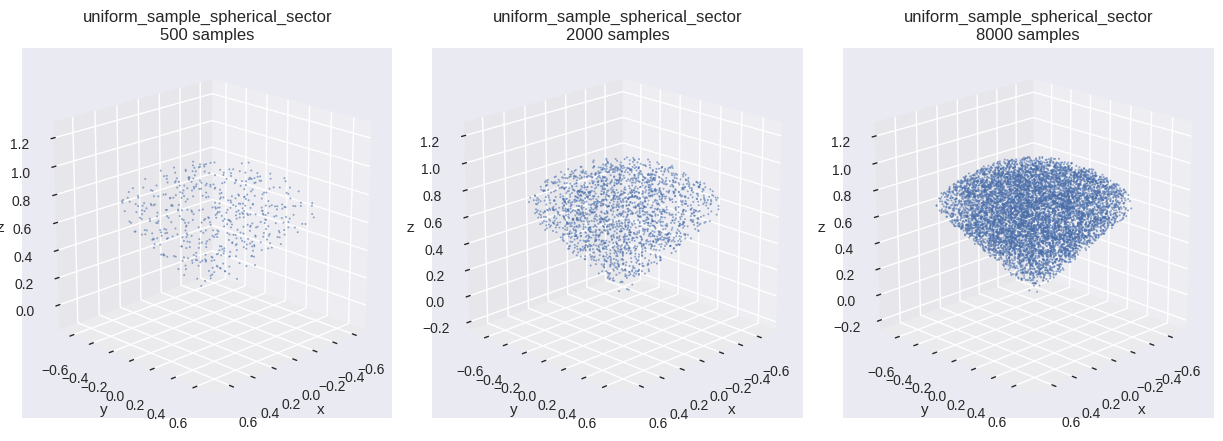

In [ ]:
def uniform_sample_spherical_sector(u0, u1, u2, *, cos_theta_max=np.pi):
    radius = np.cbrt(u0)
    c = 1.0 - (1.0 - cos_theta_max) * u1
    s = np.sqrt(1.0 - c * c)
    phi = 2.0 * np.pi * u2
    w = (s * np.cos(phi), s * np.sin(phi), c)
    return radius[:, np.newaxis] * np.stack(w, axis=-1)


fn = uniform_sample_spherical_sector  # type: ignore
fn_kwargs = {"cos_theta_max": np.cos(0.25 * np.pi)}
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "fn_kwargs": fn_kwargs, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

### 円柱（solid cylinder）内の一様分布

確率変数 $\boldsymbol{X}$ が領域 $V$ 内に一様分布するとする．

$$
V: \boldsymbol{x}(\rho,\phi,z)=
\begin{pmatrix}
\rho\cos\phi\\
\rho\sin\phi\\
z
\end{pmatrix}
,\quad
0\le\rho\le R,\,0\le\phi\lt 2\pi,\,0\le z\le H
$$

同時確率密度関数は領域 $V$ で定数 $c$ であり，正規化条件を考える．体積要素は，

$$
dV
=\left|\frac{\partial(x,y,z)}{\partial(\rho,\phi,z)}\right|\,d\rho d\phi dz
=\rho\,d\rho d\phi dz
$$

したがって，

$$
1
=\int_{V} c\,dV
=\int_{0}^{H}\int_{0}^{2\pi}\int_{0}^{R} c\rho\,d\rho d\phi dz
=c\cdot \pi R^{2}H
$$

同時確率密度関数は，

$$
p_{\boldsymbol{X}}(\boldsymbol{x})
=\frac{1}{\pi R^{2}H}
,\quad
p_{\mathrm{P},\Phi,Z}(\rho,\phi,z)
=p_{\boldsymbol{X}}(\boldsymbol{x})\frac{dV}{d\rho d\phi dz}
=\frac{\rho}{\pi R^{2}H}
$$

周辺確率密度関数は，

$$
\begin{align*}
p_{\mathrm{P}}(\rho)
&=\int_{0}^{H}\int_{0}^{2\pi} p_{\mathrm{P},\Phi,Z}(\rho,\phi,z)\,d\phi dz
=\frac{2\rho}{R^{2}}\\
p_{\Phi}(\phi)
&=\int_{0}^{H}\int_{0}^{R} p_{\mathrm{P},\Phi,Z}(\rho,\phi,z)\,d\rho dz
=\frac{1}{2\pi}\\
p_{Z}(z)
&=\int_{0}^{2\pi}\int_{0}^{R} p_{\mathrm{P},\Phi,Z}(\rho,\phi,z)\,d\rho d\phi
=\frac{1}{H}
\end{align*}
$$

累積分布関数は，

$$
P_{\mathrm{P}}(\rho)
=\int_{0}^{\rho} p_{\mathrm{P}}(t)\,dt
=\frac{\rho^{2}}{R^{2}}
,\quad
P_{\Phi}(\phi)
=\int_{0}^{\phi} p_{\Phi}(t)\,dt
=\frac{\phi}{2\pi}
,\quad
P_{Z}(z)
=\int_{0}^{z} p_{Z}(t)\,dt
=\frac{z}{H}
$$

逆関数は，

$$
P^{-1}_{\mathrm{P}}(\zeta_{1})
=R\sqrt{\zeta_{1}}
,\quad
P^{-1}_{\Phi}(\zeta_{2})
=2\pi\zeta_{2}
,\quad
P^{-1}_{Z}(\zeta_{3})
=H\zeta_{3}
$$

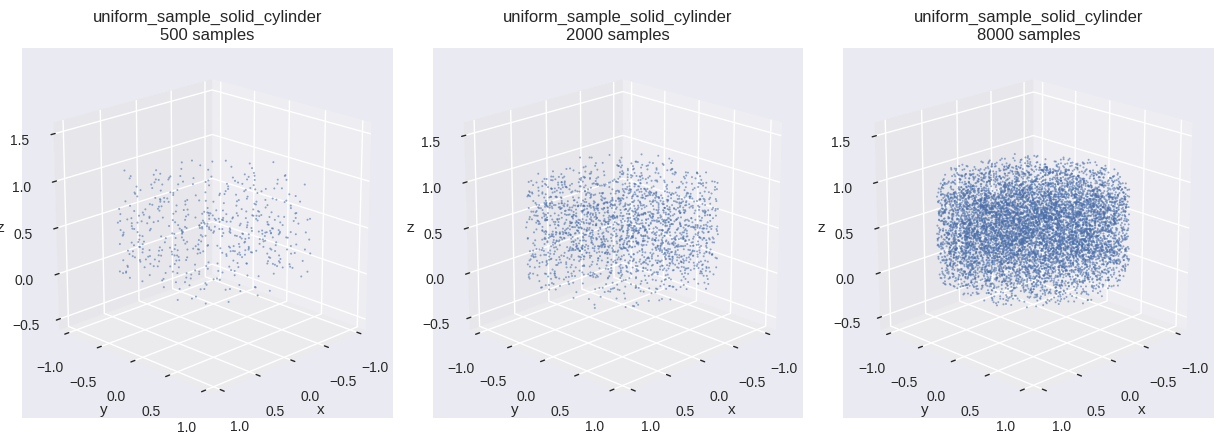

In [ ]:
def uniform_sample_solid_cylinder(u0, u1, u2):
    rho = np.sqrt(u0)
    phi = 2.0 * np.pi * u1
    w = (rho * np.cos(phi), rho * np.sin(phi), u2)
    return np.stack(w, axis=-1)


fn = uniform_sample_solid_cylinder  # type: ignore
title = f"{fn.__name__}\n{{}} samples"
distr_infos = [{"fn": fn, "num_samples": n, "title": title.format(n)} for n in SAMPLE_SIZES]

plot_distributions_3d(distr_infos, nrows_ncols=(int(math.ceil(len(distr_infos) / 3)), 3))

## References

- Pharr, M., Jakob, W., & Humphreys, G. (n.d.). *2D sampling with multidimensional transformations*. Physically Based Rendering: From Theory To Implementation. https://www.pbr-book.org/3ed-2018/Monte_Carlo_Integration/2D_Sampling_with_Multidimensional_Transformations
- Kerbl, B. (n.d.). *Rendering: Importance sampling*. Research Division of Computer Graphics, Institute of Visual Computing & Human-Centered Technology, TU Wien, Austria. https://www.cg.tuwien.ac.at/sites/default/files/course/4411/attachments/06_importance_sampling_0.pdf
- Walter, B. (2005, April 29). *Notes on the ward BRDF*. Cornell Program of Computer Graphics. https://www.graphics.cornell.edu/~bjw/wardnotes.pdf
- Inverse transform sampling. (2025, August 26). In *Wikipedia*. https://en.wikipedia.org/w/index.php?title=Inverse_transform_sampling&oldid=1307944637